In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
from pathlib import Path
from tqdm import tqdm

from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.pipeline.manifest_aptos import build_aptos_manifest
from src.retina_biomarkers.pipeline.stage3_infer_vessels import (
    make_run_id_stage3, VesselContext, stage3_infer_one
)

APTOS_ROOT = Path("../../data/raw/APTOS2019")         
CACHE_ROOT = Path("../../outputs/aptos_cache")

RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"        # stage1
CKPT_PATH = "../../outputs/checkpoints/final/[ALL] MATHFI.pth"  # your vessel ckpt

cfg = PipelineConfig(
    image_size=512,
    threshold=0.5,
    use_fov_in_model=False,
)

RUN_ID_STAGE3 = make_run_id_stage3(cfg, CKPT_PATH, prefix="aptos2019")
print("RUN_ID_STAGE3:", RUN_ID_STAGE3)

items = build_aptos_manifest(APTOS_ROOT)
print("items:", len(items))

vessel_ctx = VesselContext(CKPT_PATH)  # loads once

ok = skip = fail = 0
for it in tqdm(items):
    try:
        r = stage3_infer_one(
            image_id=it.image_id,
            cfg=cfg,
            ckpt_path=CKPT_PATH,
            cache_root=CACHE_ROOT,
            run_id_stage1=RUN_ID_STAGE1,
            run_id_stage3=RUN_ID_STAGE3,
            vessel_ctx=vessel_ctx,
            save_pred_mask=True,     # optional
            prob_dtype="float16",    # recommended for space
            save_preview_png=False,  # set True for first 10 only
            overwrite=False
        )
        if r["status"] == "ok": ok += 1
        else: skip += 1
    except Exception as e:
        fail += 1
        print("[FAIL]", it.image_id, e)

print(f"done. ok={ok} skipped={skip} fail={fail}")
print("stage3 cache:", CACHE_ROOT / RUN_ID_STAGE3 / "stage3")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


RUN_ID_STAGE3: aptos2019_stage3_cd3f6ffabc
items: 3665


100%|██████████| 3665/3665 [42:34<00:00,  1.43it/s]  

done. ok=3665 skipped=0 fail=0
stage3 cache: ..\..\outputs\aptos_cache\aptos2019_stage3_cd3f6ffabc\stage3


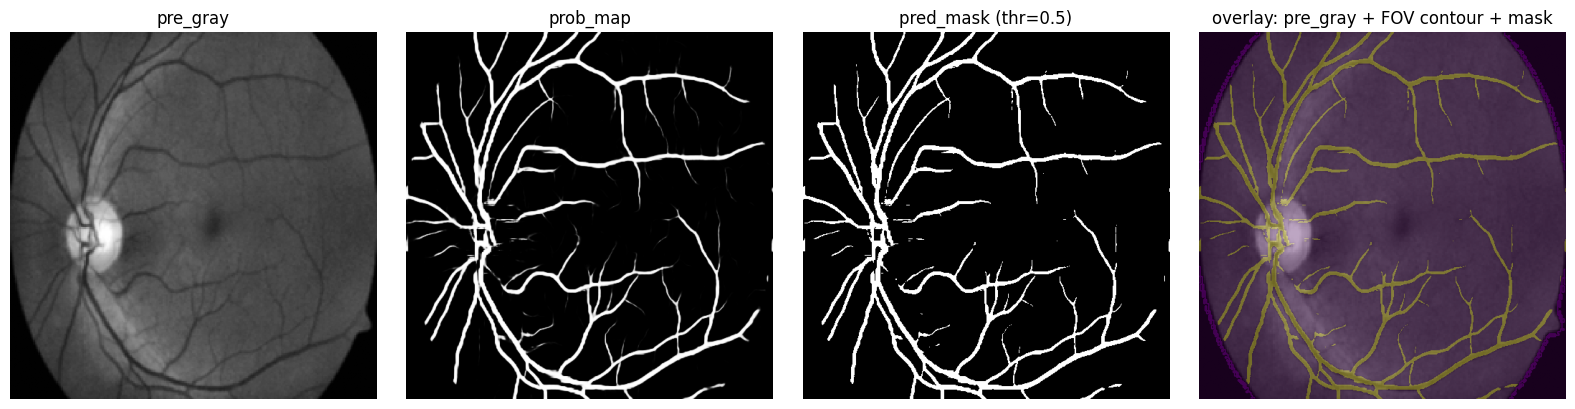

In [8]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"
image_id = "No_DR/img555"
THR = 0.5

def safe_id(s): return s.replace("/", "__")

s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
s3 = CACHE_ROOT / RUN_ID_STAGE3 / "stage3" / safe_id(image_id)

pre_gray = np.load(s1/"img_1hw.npy")[0]
fov = (np.load(s1/"fov_1hw.npy")[0] > 0.5)
prob = np.load(s3/"prob_map.npy").astype(np.float32)

# use cached mask if it exists, else compute from prob
mask_path = s3/"pred_mask_u8.npy"
if mask_path.exists():
    mask = (np.load(mask_path) > 0)
else:
    mask = (prob >= THR)

# clamp mask to FOV for cleaner viewing (optional)
mask_fov = mask & fov

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(pre_gray, cmap="gray")
plt.title("pre_gray")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(prob, cmap="gray")
plt.title("prob_map")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(mask_fov.astype(np.uint8), cmap="gray")
plt.title(f"pred_mask (thr={THR})")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(pre_gray, cmap="gray")
plt.contour(fov.astype(float), levels=[0.5], linewidths=1.0)
plt.imshow(mask_fov.astype(float), alpha=0.35)  # mask overlay
plt.title("overlay: pre_gray + FOV contour + mask")
plt.axis("off")

plt.tight_layout()
plt.show()


In [10]:
import numpy as np
from pathlib import Path
import random

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"
s3root = CACHE_ROOT / RUN_ID_STAGE3 / "stage3"

dirs = [p for p in s3root.iterdir() if p.is_dir()]
for d in random.sample(dirs, k=min(10, len(dirs))):
    prob = np.load(d/"prob_map.npy").astype(np.float32)
    print(d.name, "min/max/mean:", float(prob.min()), float(prob.max()), float(prob.mean()))


Moderate__img739 min/max/mean: 0.0 1.0 0.05070466548204422
Moderate__img737 min/max/mean: 0.0 1.0 0.07253146171569824
No_DR__img652 min/max/mean: 0.0 1.0 0.08362777531147003
No_DR__img1013 min/max/mean: 0.0 1.0 0.051051247864961624
Mild__img86 min/max/mean: 0.0 1.0 0.04905751347541809
Moderate__img681 min/max/mean: 0.0 1.0 0.04993988946080208
No_DR__img195 min/max/mean: 0.0 1.0 0.0689966157078743
No_DR__img1726 min/max/mean: 0.0 1.0 0.10282641649246216
Moderate__img381 min/max/mean: 0.0 1.0 0.08578507602214813
Moderate__img113 min/max/mean: 0.0 1.0 0.07532613724470139
